In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nine-languages-xfact/x_fact_test_clean_9L.csv
/kaggle/input/nine-languages-xfact/x_fact_train_oversampled_9L.csv


In [12]:
!pip install transformers datasets accelerate peft torch torchvision torchaudio

In [13]:
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
from datasets import Dataset

In [14]:
train_df = pd.read_csv("/kaggle/input/nine-languages-xfact/x_fact_train_oversampled_9L.csv")
test_df = pd.read_csv("/kaggle/input/nine-languages-xfact/x_fact_test_clean_9L.csv")

print("Train Data Sample:")
print(train_df.head())

print("\nTest Data Sample:")
print(test_df.head())

label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["label"])
test_df["label"] = label_encoder.transform(test_df["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nLabel Mapping:", label_mapping)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["claim"].tolist(), train_df["label"].tolist(), test_size=0.1, random_state=42
)

test_texts = test_df["claim"].tolist()
test_labels = test_df["label"].tolist()

num_labels = len(set(train_labels))  # Number of unique labels
print(f"\nNumber of classes: {num_labels}")


Train Data Sample:
                                               claim         label
0  U nas mniej więcej połowa składów tramwajowych...         false
1  ...son on iki yılda TİKA yurt dışı ofis sayımı...   mostly true
2  Rusya kaynaklı nükleer sızıntı ve radyoaktif b...  mostly false
3  NASA vs Diyanet - 4: Kadının toplumsal rolüne ...          true
4  “Realizamos la mayor campaña de reclutamiento ...   mostly true

Test Data Sample:
                                               claim         label  \
0  Anton Hofreiter: „Wir können kriminelle Flücht...         false   
1  Skok (na Trybunał Konstytucyjny - przyp. Demag...  mostly false   
2  2017’de tarımsal kesime 12,7 milyar lira deste...          true   
3  Eşcinseller kan verme konusunda risk grubundad...         false   
4  წელს, 2015 წელთან შედარებით, საქართველოს აეროპ...          true   

  source_language  
0              de  
1              pl  
2              tr  
3              tr  
4              ka  

Label Mapping: {'f

In [15]:
model_name = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(texts):
    return tokenizer(texts, truncation=True, padding="max_length", max_length=512)

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)
test_encodings = tokenize_function(test_texts)

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels
})

val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_labels
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels
})


In [16]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=128, 
    lora_alpha=256,
    lora_dropout=0.2
)

# Apply LoRA using PEFT
model = get_peft_model(model, peft_config)

model.print_trainable_parameters()


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 13,636,612 || all params: 573,531,144 || trainable%: 2.3777


In [17]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=15,
    learning_rate=0.001, 
    gradient_accumulation_steps=4,  
    gradient_checkpointing=True,  
    logging_dir="./logs",
    logging_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True
)


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted"),  # Weighted for multi-class
        "recall": recall_score(labels, predictions, average="weighted")  # Weighted recall
    }


In [19]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [20]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


/usr/local/lib/python3.10/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Recall
1,1.332200,1.281825,0.423033,0.385778,0.423033
2,1.278900,1.318792,0.336374,0.258945,0.336374
3,1.269400,1.265828,0.392246,0.353119,0.392246
4,1.263300,1.204004,0.446978,0.386543,0.446978
5,1.244700,1.207654,0.458381,0.436108,0.458381
6,1.244000,1.221067,0.462942,0.427875,0.462942
7,1.238200,1.198245,0.460661,0.448657,0.460661
8,1.225700,1.198540,0.462942,0.465872,0.462942
9,1.229500,1.195682,0.475485,0.449515,0.475485
10,1.226000,1.193849,0.445838,0.450797,0.445838


/usr/local/lib/python3.10/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/

TrainOutput(global_step=1845, training_loss=1.2404424486444572, metrics={'train_runtime': 10108.0134, 'train_samples_per_second': 11.704, 'train_steps_per_second': 0.183, 'total_flos': 1.1432172071726285e+17, 'train_loss': 1.2404424486444572, 'epoch': 14.884381338742394})

In [21]:
test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)

/usr/local/lib/python3.10/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Test Results: {'eval_loss': 1.232561707496643, 'eval_accuracy': 0.40668348045397223, 'eval_f1': 0.42000960070033583, 'eval_recall': 0.40668348045397223, 'eval_runtime': 95.486, 'eval_samples_per_second': 16.61, 'eval_steps_per_second': 1.047, 'epoch': 14.884381338742394}


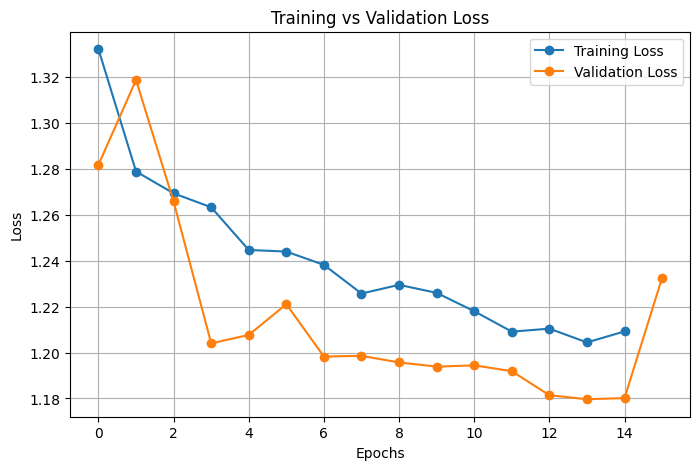

In [22]:
history = trainer.state.log_history

train_losses = [h["loss"] for h in history if "loss" in h]
val_losses = [h["eval_loss"] for h in history if "eval_loss" in h]

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()